Feature Scaling, Cost convergence checking, Learning rate , multi_variable gradient descent for linear model.

    1. Feature Scaling

        x_j = (x_j/max)

        mean normalization: x_j = (x_j - mu_j)/(max-min)

        z-score normalization: x_j = (x_j - mu_j)/sigma_j

2. Cost Convergence Checking

    if cost descrese by every iteration, that means it's working well. 
    Autoconvergence checking: epsilon = 10e-3 (0.001). if J(w,b) <= epsilon by every iteration, then it's 
    convergenced.

3. Learning rate : alpha = 0.001, 0.01, 0.1, 1 
    
4. gradient descent for multiple variable

    model: f_wb = W.X + b 
    
    cost func: J_wb = (1/(2m)) summation of (f_wb_i - y_i)**2

    gradient: d/dw_j (J_wb) = (1/m) summ (f_wb_i - y_i)*x_ij

              d/db (J_wb) = (1/m) summ (f_wb_i - y_i)

    gredient descent: w_j = w_j - alpha * d/dw_j (J_wb)

                    b = b - alpha * d/db (J_wb)

    plot (completed previously)

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=2)
plt.style.use('seaborn-v0_8')

In [3]:
X_train = np.array([[1.24e+03, 3.00e+00, 1.00e+00, 6.40e+01],
                    [1.95e+03, 3.00e+00, 2.00e+00, 1.70e+01],
                    [1.72e+03, 3.00e+00, 2.00e+00, 4.20e+01],
                    [1.96e+03, 3.00e+00, 2.00e+00, 1.50e+01],
                    [1.31e+03, 2.00e+00, 1.00e+00, 1.40e+01],
                    [8.64e+02, 2.00e+00, 1.00e+00, 6.60e+01],
                    [1.84e+03, 3.00e+00, 1.00e+00, 1.70e+01],
                    [1.03e+03, 3.00e+00, 1.00e+00, 4.30e+01],
                    [3.19e+03, 4.00e+00, 2.00e+00, 8.70e+01],
                    [7.88e+02, 2.00e+00, 1.00e+00, 8.00e+01],
                    [1.20e+03, 2.00e+00, 2.00e+00, 1.70e+01],
                    [1.56e+03, 2.00e+00, 1.00e+00, 1.80e+01],
                    [1.43e+03, 3.00e+00, 1.00e+00, 2.00e+01],
                    [1.22e+03, 2.00e+00, 1.00e+00, 1.50e+01],
                    [1.09e+03, 2.00e+00, 1.00e+00, 6.40e+01],
                    [8.48e+02, 1.00e+00, 1.00e+00, 1.70e+01],
                    [1.68e+03, 3.00e+00, 2.00e+00, 2.30e+01],
                    [1.77e+03, 3.00e+00, 2.00e+00, 1.80e+01],
                    [1.04e+03, 3.00e+00, 1.00e+00, 4.40e+01],
                    [1.65e+03, 2.00e+00, 1.00e+00, 2.10e+01],
                    [1.09e+03, 2.00e+00, 1.00e+00, 3.50e+01],
                    [1.32e+03, 3.00e+00, 1.00e+00, 1.40e+01],
                    [1.59e+03, 0.00e+00, 1.00e+00, 2.00e+01],
                    [9.72e+02, 2.00e+00, 1.00e+00, 7.30e+01],
                    [1.10e+03, 3.00e+00, 1.00e+00, 3.70e+01],
                    [1.00e+03, 2.00e+00, 1.00e+00, 5.10e+01],
                    [9.04e+02, 3.00e+00, 1.00e+00, 5.50e+01],
                    [1.69e+03, 3.00e+00, 1.00e+00, 1.30e+01],
                    [1.07e+03, 2.00e+00, 1.00e+00, 1.00e+02],
                    [1.42e+03, 3.00e+00, 2.00e+00, 1.90e+01],
                    [1.16e+03, 3.00e+00, 1.00e+00, 5.20e+01],
                    [1.94e+03, 3.00e+00, 2.00e+00, 1.20e+01],
                    [1.22e+03, 2.00e+00, 2.00e+00, 7.40e+01],
                    [2.48e+03, 4.00e+00, 2.00e+00, 1.60e+01],
                    [1.20e+03, 2.00e+00, 1.00e+00, 1.80e+01],
                    [1.84e+03, 3.00e+00, 2.00e+00, 2.00e+01],
                    [1.85e+03, 3.00e+00, 2.00e+00, 5.70e+01],
                    [1.66e+03, 3.00e+00, 2.00e+00, 1.90e+01],
                    [1.10e+03, 2.00e+00, 2.00e+00, 9.70e+01],
                    [1.78e+03, 3.00e+00, 2.00e+00, 2.80e+01],
                    [2.03e+03, 4.00e+00, 2.00e+00, 4.50e+01],
                    [1.78e+03, 4.00e+00, 2.00e+00, 1.07e+02],
                    [1.07e+03, 2.00e+00, 1.00e+00, 1.00e+02],
                    [1.55e+03, 3.00e+00, 1.00e+00, 1.60e+01],
                    [1.95e+03, 3.00e+00, 2.00e+00, 1.60e+01],
                    [1.22e+03, 2.00e+00, 2.00e+00, 1.20e+01],
                    [1.62e+03, 3.00e+00, 1.00e+00, 1.60e+01],
                    [8.16e+02, 2.00e+00, 1.00e+00, 5.80e+01],
                    [1.35e+03, 3.00e+00, 1.00e+00, 2.10e+01],
                    [1.57e+03, 3.00e+00, 1.00e+00, 1.40e+01],
                    [1.49e+03, 3.00e+00, 1.00e+00, 5.70e+01],
                    [1.51e+03, 2.00e+00, 1.00e+00, 1.60e+01],
                    [1.10e+03, 3.00e+00, 1.00e+00, 2.70e+01],
                    [1.76e+03, 3.00e+00, 2.00e+00, 2.40e+01],
                    [1.21e+03, 2.00e+00, 1.00e+00, 1.40e+01],
                    [1.47e+03, 3.00e+00, 2.00e+00, 2.40e+01],
                    [1.77e+03, 3.00e+00, 2.00e+00, 8.40e+01],
                    [1.65e+03, 3.00e+00, 1.00e+00, 1.90e+01],
                    [1.03e+03, 3.00e+00, 1.00e+00, 6.00e+01],
                    [1.12e+03, 2.00e+00, 2.00e+00, 1.60e+01],
                    [1.15e+03, 3.00e+00, 1.00e+00, 6.20e+01],
                    [8.16e+02, 2.00e+00, 1.00e+00, 3.90e+01],
                    [1.04e+03, 3.00e+00, 1.00e+00, 2.50e+01],
                    [1.39e+03, 3.00e+00, 1.00e+00, 6.40e+01],
                    [1.60e+03, 3.00e+00, 2.00e+00, 2.90e+01],
                    [1.22e+03, 3.00e+00, 1.00e+00, 6.30e+01],
                    [1.07e+03, 2.00e+00, 1.00e+00, 1.00e+02],
                    [2.60e+03, 4.00e+00, 2.00e+00, 2.20e+01],
                    [1.43e+03, 3.00e+00, 1.00e+00, 5.90e+01],
                    [2.09e+03, 3.00e+00, 2.00e+00, 2.60e+01],
                    [1.79e+03, 4.00e+00, 2.00e+00, 4.90e+01],
                    [1.48e+03, 3.00e+00, 2.00e+00, 1.60e+01],
                    [1.04e+03, 3.00e+00, 1.00e+00, 2.50e+01],
                    [1.43e+03, 3.00e+00, 1.00e+00, 2.20e+01],
                    [1.16e+03, 3.00e+00, 1.00e+00, 5.30e+01],
                    [1.55e+03, 3.00e+00, 2.00e+00, 1.20e+01],
                    [1.98e+03, 3.00e+00, 2.00e+00, 2.20e+01],
                    [1.06e+03, 3.00e+00, 1.00e+00, 5.30e+01],
                    [1.18e+03, 2.00e+00, 1.00e+00, 9.90e+01],
                    [1.36e+03, 2.00e+00, 1.00e+00, 1.70e+01],
                    [9.60e+02, 3.00e+00, 1.00e+00, 5.10e+01],
                    [1.46e+03, 3.00e+00, 2.00e+00, 1.60e+01],
                    [1.45e+03, 3.00e+00, 2.00e+00, 2.50e+01],
                    [1.21e+03, 2.00e+00, 1.00e+00, 1.50e+01],
                    [1.55e+03, 3.00e+00, 2.00e+00, 1.60e+01],
                    [8.82e+02, 3.00e+00, 1.00e+00, 4.90e+01],
                    [2.03e+03, 4.00e+00, 2.00e+00, 4.50e+01],
                    [1.04e+03, 3.00e+00, 1.00e+00, 6.20e+01],
                    [1.62e+03, 3.00e+00, 1.00e+00, 1.60e+01],
                    [8.03e+02, 2.00e+00, 1.00e+00, 8.00e+01],
                    [1.43e+03, 3.00e+00, 2.00e+00, 2.10e+01],
                    [1.66e+03, 3.00e+00, 1.00e+00, 6.10e+01],
                    [1.54e+03, 3.00e+00, 1.00e+00, 1.60e+01],
                    [9.48e+02, 3.00e+00, 1.00e+00, 5.30e+01],
                    [1.22e+03, 2.00e+00, 2.00e+00, 1.20e+01],
                    [1.43e+03, 2.00e+00, 1.00e+00, 4.30e+01],
                    [1.66e+03, 3.00e+00, 2.00e+00, 1.90e+01],
                    [1.21e+03, 3.00e+00, 1.00e+00, 2.00e+01],
                    [1.05e+03, 2.00e+00, 1.00e+00, 6.50e+01]])
X_features = ["size(sqft)","bedrooms","floors","age"]
y_train = np.array([300.  , 509.8 , 394.  , 540.  , 415.  , 230.  , 560.  , 294.  ,
                    718.2 , 200.  , 302.  , 468.  , 374.2 , 388.  , 282.  , 311.8 ,
                    401.  , 449.8 , 301.  , 502.  , 340.  , 400.28, 572.  , 264.  ,
                    304.  , 298.  , 219.8 , 490.7 , 216.96, 368.2 , 280.  , 526.87,
                    237.  , 562.43, 369.8 , 460.  , 374.  , 390.  , 158.  , 426.  ,
                    390.  , 277.77, 216.96, 425.8 , 504.  , 329.  , 464.  , 220.  ,
                    358.  , 478.  , 334.  , 426.98, 290.  , 463.  , 390.8 , 354.  ,
                    350.  , 460.  , 237.  , 288.3 , 282.  , 249.  , 304.  , 332.  ,
                    351.8 , 310.  , 216.96, 666.34, 330.  , 480.  , 330.3 , 348.  ,
                    304.  , 384.  , 316.  , 430.4 , 450.  , 284.  , 275.  , 414.  ,
                    258.  , 378.  , 350.  , 412.  , 373.  , 225.  , 390.  , 267.4 ,
                    464.  , 174.  , 340.  , 430.  , 440.  , 216.  , 329.  , 388.  ,
                    390.  , 356.  , 257.8 ])

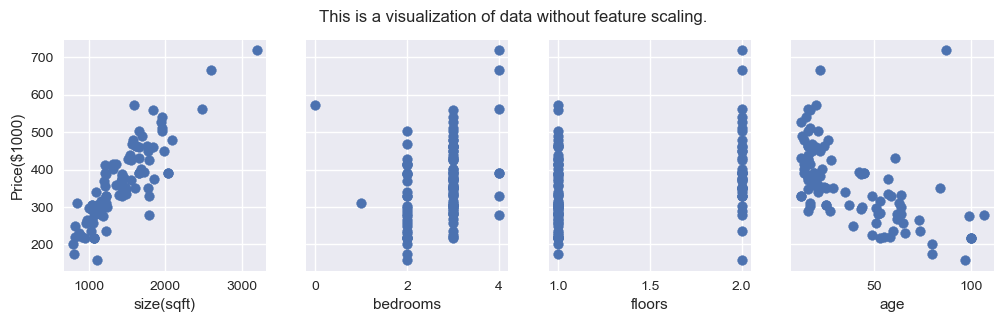

In [4]:
fig,ax = plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    # X_features = ["size(sqft)","bedrooms","floors","age"]
    ax[i].scatter(X_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price($1000)")
fig.suptitle("This is a visualization of data without feature scaling.")
plt.show()

In [5]:
def zscore_normalize(X):

    mu = np.mean(X,axis=0)
    sigma = np.std(X,axis=0)

    X_norm = (X - mu)/sigma 

    return (X_norm, mu, sigma)

In [6]:
X_norm, mu, sigma = zscore_normalize(X_train)
print(mu) 
print(sigma)
print(X_norm)

[1.42e+03 2.72e+00 1.38e+00 3.84e+01]
[411.4    0.65   0.49  25.78]
[[-4.34e-01  4.34e-01 -7.89e-01  9.94e-01]
 [ 1.29e+00  4.34e-01  1.27e+00 -8.30e-01]
 [ 7.33e-01  4.34e-01  1.27e+00  1.40e-01]
 [ 1.32e+00  4.34e-01  1.27e+00 -9.07e-01]
 [-2.63e-01 -1.10e+00 -7.89e-01 -9.46e-01]
 [-1.35e+00 -1.10e+00 -7.89e-01  1.07e+00]
 [ 1.02e+00  4.34e-01 -7.89e-01 -8.30e-01]
 [-9.44e-01  4.34e-01 -7.89e-01  1.79e-01]
 [ 4.31e+00  1.97e+00  1.27e+00  1.89e+00]
 [-1.53e+00 -1.10e+00 -7.89e-01  1.61e+00]
 [-5.31e-01 -1.10e+00  1.27e+00 -8.30e-01]
 [ 3.44e-01 -1.10e+00 -7.89e-01 -7.91e-01]
 [ 2.82e-02  4.34e-01 -7.89e-01 -7.13e-01]
 [-4.82e-01 -1.10e+00 -7.89e-01 -9.07e-01]
 [-7.98e-01 -1.10e+00 -7.89e-01  9.94e-01]
 [-1.39e+00 -2.63e+00 -7.89e-01 -8.30e-01]
 [ 6.36e-01  4.34e-01  1.27e+00 -5.97e-01]
 [ 8.55e-01  4.34e-01  1.27e+00 -7.91e-01]
 [-9.20e-01  4.34e-01 -7.89e-01  2.18e-01]
 [ 5.63e-01 -1.10e+00 -7.89e-01 -6.74e-01]
 [-7.98e-01 -1.10e+00 -7.89e-01 -1.31e-01]
 [-2.39e-01  4.34e-01 -7.89e-

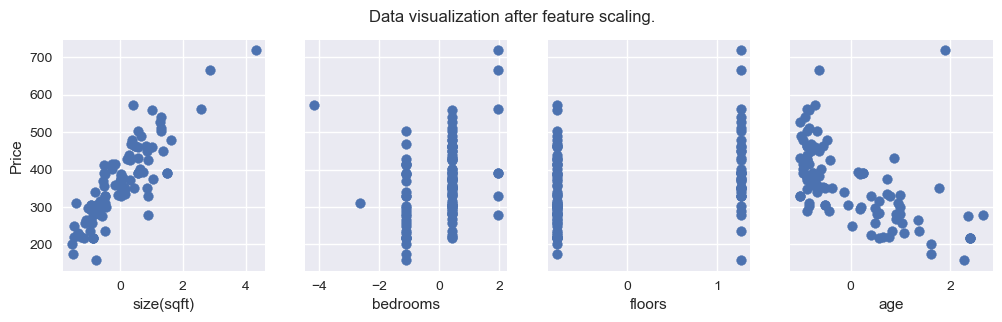

In [7]:
fig,ax = plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_norm[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price")
fig.suptitle("Data visualization after feature scaling.")
plt.show()

In [8]:
# Gradient descent with multiple features(feature scaling)
# model
def f_wb(x,w,b):
    predict = np.dot(w,x) + b 
    return predict 

# cost function
def J_wb(x,y,w,b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb_i = np.dot(w,x[i]) + b
        cost += (f_wb_i - y[i])**2
    result = cost/(2*m)
    return result

# gradient (derivative)
def gradient(x,y,w,b):
    m,n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0
    
    for i in range(m):
        f_wb_i = np.dot(w,x[i]) + b

        for j in range(n):
            dj_dw[j] += (f_wb_i - y[i]) * x[i,j]

        dj_db += f_wb_i - y[i]
    return (dj_dw/m, dj_db/m)

# gradient descent 
def gradient_descent(x,y,w_in,b_in,alpha,iteration,cost_func,grad_func):
    w = w_in 
    b = b_in 
    J_hist = []
    process = []

    for i in range(iteration):
        dj_dw, dj_db = grad_func(x,y,w,b)

        w = w - (alpha*dj_dw)
        b = b - (alpha*dj_db)

        cost = cost_func(x,y,w,b)

        if i<10000:
            J_hist.append(cost)
        if i % math.ceil(iteration/10) == 0:
            process.append({
                "Iter": i,
                "Cost": cost,
                "dj_db": dj_db,
                "dj_dw": dj_dw
            })
    return w,b,J_hist,process 

In [40]:
_,n = X_train.shape
w_in = np.zeros(n)
b_in = 0
alpha = 0.001
iter = 10000
w_final,b_final,J_hist,process = gradient_descent(X_norm,y_train,w_in,b_in,alpha,iter,J_wb,gradient)

print(f"W Final: {w_final}")
print(f"b Final: {b_final}")
print()
df = pd.DataFrame(process)
print(df)


W Final: [107.77 -19.95 -31.05 -38.42]
b Final: 363.13965563169154

   Iter          Cost       dj_db  \
0     0  71223.981397 -363.156061   
1  1000  10223.884466 -133.530822   
2  2000   1922.891491  -49.098672   
3  3000    629.069640  -18.053357   
4  4000    365.118162   -6.638137   
5  5000    284.045319   -2.440813   
6  6000    249.897279   -0.897476   
7  7000    233.418210   -0.329998   
8  8000    225.116941   -0.121339   
9  9000    220.883810   -0.044616   

                                               dj_dw  
0  [-89.18663892658859, -29.51836295042385, -32.8...  
1  [-26.767066055799177, 5.7338377567173655, 8.62...  
2  [-14.78915343955272, 6.510789809525225, 9.4714...  
3  [-10.109220001271431, 4.710537453418781, 6.854...  
4  [-7.200416985536067, 3.3324032072578684, 4.740...  
5  [-5.1590299960107515, 2.3890704132745664, 3.27...  
6  [-3.697510021971304, 1.7280646203153809, 2.280...  
7  [-2.6491205177948136, 1.2536792867479243, 1.59...  
8  [-1.8974551345926782, 0.90

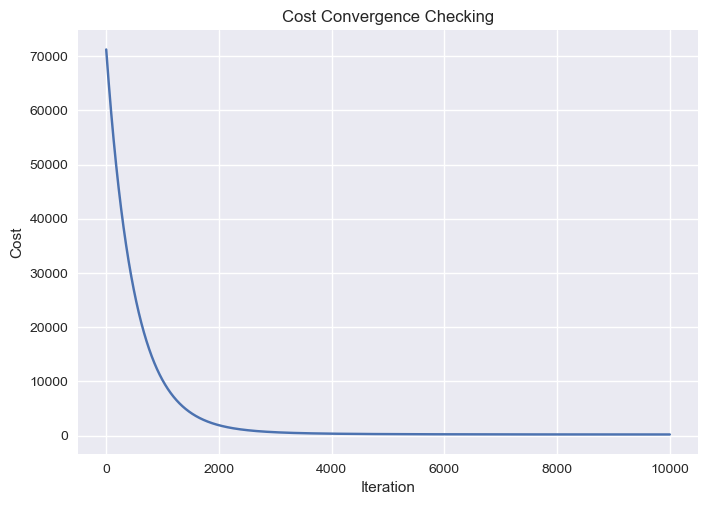

In [41]:
plt.plot(J_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Convergence Checking")
plt.show()

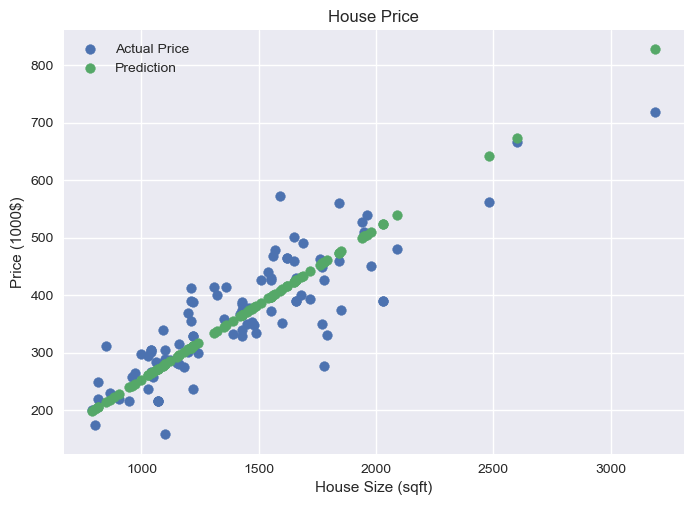

In [42]:
plt.scatter(X_train[:,0],y_train,label="Actual Price")
plt.scatter(X_train[:,0], w_final[0]*X_norm[:,0] + b_final,label="Prediction")
plt.xlabel("House Size (sqft)")
plt.ylabel("Price (1000$)")
plt.title("House Price")
plt.legend()
plt.show()

In [44]:
# prediction
features = np.array([2500,3,1,45])
x_norm = (features-mu)/sigma
predict = np.dot(w_final,x_norm) + b_final
print(f"The Price of the house is ${predict*1000:,.0f}")

The Price of the house is $652,469
